### Chronological split

Shah's benchmark splits at random across 1996-2022, so 19 of 496 test sentences
appear verbatim in the training set -- the Fed reuses boilerplate. This asks whether
the headline numbers survive an honest temporal split: train on everything up to
2019, test on 2020-22.

Reads `../results.csv`, writes `chrono_comparison.png`.

In [1]:
import sys

sys.path.insert(0, "..")
from config import RESULTS_DIR

import matplotlib.pyplot as plt
import polars as pl
from matplotlib.patches import Rectangle

d = pl.read_csv(RESULTS_DIR / "results.csv")
rnd = (
    d.filter(pl.col("corpus") == "twd")
    .group_by("model")
    .agg(
        pl.col("macro_f1").mean().alias("r"), pl.col("macro_f1").std(ddof=0).alias("sd")
    )
)
chr_ = (
    d.filter(pl.col("corpus") == "twd-chrono")
    .filter(~pl.col("model").str.starts_with("frozen:"))
    .filter(~pl.col("model").str.contains("deberta"))
    .select(["model", "macro_f1"])
    .rename({"macro_f1": "c"})
)
# fine-tuned encoders only -- the chrono run covers just those
j = rnd.join(chr_, on="model", how="inner").sort("r", descending=True)

COLORS = {
    "fine-tuned": "#cfe3f7",
    "zero-shot LLM": "#cfeddb",
    "frozen": "#fbe6c2",
    "count-based": "#e6d9f2",
    "rule-based": "#e2e2e2",
    "chance": "#f5d5d5",
}
PRETTY = {
    "roberta-large": "RoBERTa-large",
    "roberta-base": "RoBERTa-base",
    "bert-large-uncased": "BERT-large",
    "bert-base-uncased": "BERT-base",
    "flang-bert": "FLANG-BERT",
    "flang-roberta": "FLANG-RoBERTa",
    "claude-fable-5": "Fable 5",
    "claude-opus-4-8": "Opus 4.8",
    "claude-sonnet-5": "Sonnet 5",
    "claude-haiku-4-5": "Haiku 4.5",
    "bow": "bag-of-words",
    "word2vec": "word2vec",
    "rule-based": "rule-based",
    "random": "random guess",
    "always-neutral": "always neutral",
}


def kind(m):
    if m.startswith("frozen:"):
        return "frozen"
    if m.startswith("zero-shot:"):
        return "zero-shot LLM"
    if m in ("random", "always-neutral"):
        return "chance"
    if m in ("bow", "word2vec"):
        return "count-based"
    if m == "rule-based":
        return "rule-based"
    return "fine-tuned"


def label(m):
    name = PRETTY.get(m.split(":", 1)[-1], m.split(":", 1)[-1])
    if m.startswith("frozen:"):
        return f"frozen {name}"
    if m.startswith("zero-shot:"):
        return f"LLM {name}"
    if kind(m) == "fine-tuned":
        return f"finetuned {name}"
    return name

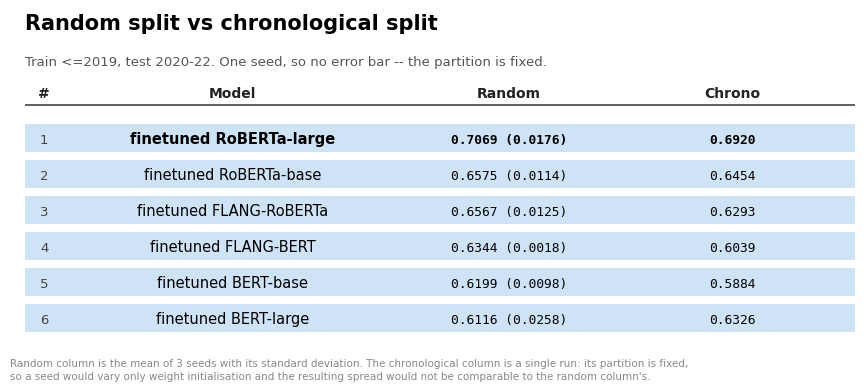

In [2]:
rows = j.to_dicts()
n = len(rows)
fig, ax = plt.subplots(figsize=(8.6, (n + 3.4) * 0.38))
ax.set_xlim(0, 10.8)
ax.set_ylim(-0.2, n + 2.9)
ax.axis("off")

ax.text(
    0, n + 2.35, "Random split vs chronological split", fontsize=15, fontweight="bold"
)
ax.text(
    0,
    n + 1.35,
    "Train <=2019, test 2020-22. One seed, so no error bar -- the partition is fixed.",
    fontsize=9.5,
    color="#555",
)

hy = n + 0.45
for x, t in [(0.25, "#"), (2.7, "Model"), (6.3, "Random"), (9.2, "Chrono")]:
    ax.text(x, hy, t, fontsize=10, fontweight="bold", ha="center", color="#222")
ax.plot([0, 10.8], [hy - 0.22, hy - 0.22], color="#333", lw=1.1)

for i, r in enumerate(rows):
    y = n - 1 - i
    fw = "bold" if i == 0 else "normal"
    ax.add_patch(
        Rectangle(
            (0, y - 0.08),
            10.8,
            0.78,
            facecolor=COLORS[kind(r["model"])],
            edgecolor="none",
        )
    )
    ax.text(0.25, y + 0.18, str(i + 1), fontsize=9.5, ha="center", color="#444")
    ax.text(2.7, y + 0.18, label(r["model"]), fontsize=10.5, fontweight=fw, ha="center")
    ax.text(
        6.3,
        y + 0.18,
        f"{r['r']:.4f} ({r['sd']:.4f})",
        fontsize=9.3,
        ha="center",
        fontweight=fw,
        family="monospace",
    )
    if r["c"] is None:
        ax.text(
            9.2,
            y + 0.18,
            "--",
            fontsize=9.3,
            ha="center",
            color="#999",
            family="monospace",
        )
    else:
        ax.text(
            9.2,
            y + 0.18,
            f"{r['c']:.4f}",
            fontsize=9.3,
            ha="center",
            fontweight=fw,
            family="monospace",
        )

fig.text(
    0.0,
    -0.02,
    "Random column is the mean of 3 seeds with its standard deviation. The chronological "
    "column is a single run: its partition is fixed,",
    fontsize=7.5,
    color="#888",
    va="top",
)
fig.text(
    0.0,
    -0.055,
    "so a seed would vary only weight initialisation and the resulting spread would not be "
    "comparable to the random column's.",
    fontsize=7.5,
    color="#888",
    va="top",
)

fig.tight_layout()
fig.savefig("chrono_comparison.png", dpi=200, bbox_inches="tight", facecolor="white")

### What it shows

- **RoBERTa-large barely moves**: 0.707 -> 0.692 (-0.015), inside its own
  random-split standard deviation (0.018). The leakage was not inflating it.
- **Deltas are small across the board** (-0.012 to -0.031); BERT-large is the one
  riser (+0.021), but its random-split mean carries the largest seed spread (0.026).
- Figure now shows fine-tuned encoders only -- the chrono run covers just those.

The chronological split reduces verbatim train/test overlap from 19 rows to 5, but
does not eliminate it: the Fed repeats boilerplate across eras, not only within them.

Two caveats for the writeup. The test set is 55% neutral against 49% overall, so some
of any movement is distribution shift rather than temporal difficulty. And the frozen
probes and LLMs have not been run on this split yet.